## Task 1.1 
### c. Evaluación de los cuatro equilibrios con los parámetros del grupo

Mediante un script de Python, calcularemos los parámetros correspondientes al grupo y evaluaremos las coordenadas exactas del equilibrio interior. Después se determinará si este es factible (coordenadas positivas).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# ==========================================
g = 1 
# ==========================================

# 1. Cálculo de parámetros según las reglas de la hoja
conjunto = ((g - 1) % 4) + 1
r1 = 1
r2 = 0.5 + 0.1 * ((g - 1) % 5)

# Diccionario con los parámetros del Conjunto de la tabla
# Llave: conjunto -> Valor: (alpha_12, alpha_21)
tabla_alphas = {
    1: (0.5, 0.6),
    2: (1.4, 1.5),
    3: (0.6, 1.5),
    4: (1.5, 0.6)
}

alpha12, alpha21 = tabla_alphas[conjunto]

print(f"--- Parámetros para el Grupo {g} ---")
print(f"Conjunto asignado: {conjunto}")
print(f"r1 = {r1}")
print(f"r2 = {r2:.2f}")
print(f"alpha_12 = {alpha12}")
print(f"alpha_21 = {alpha21}\n")

# 2. Definición de los equilibrios fijos (siempre factibles)
E1 = (0.0, 0.0)
E2 = (0.0, 1.0)
E3 = (1.0, 0.0)

# 3. Cálculo del equilibrio interior E4
denominador = 1 - (alpha12 * alpha21)
x_star = (1 - alpha12) / denominador
y_star = (1 - alpha21) / denominador
E4 = (x_star, y_star)

print("--- Puntos de Equilibrio Calculados ---")
print(f"E1: {E1} -> Siempre factible (Plataformas sin usuarios)")
print(f"E2: {E2} -> Siempre factible (Exclusión de A)")
print(f"E3: {E3} -> Siempre factible (Exclusión de B)")
print(f"E4 (Interior): ({x_star:.4f}, {y_star:.4f})")

# 4. Evaluación de factibilidad del equilibrio interior
if x_star > 0 and y_star > 0:
    print("-> El equilibrio interior E4 ES biológicamente FACTIBLE (ambas coordenadas > 0).")
else:
    print("-> El equilibrio interior E4 NO ES biológicamente factible.")

--- Parámetros para el Grupo 1 ---
Conjunto asignado: 1
r1 = 1
r2 = 0.50
alpha_12 = 0.5
alpha_21 = 0.6

--- Puntos de Equilibrio Calculados ---
E1: (0.0, 0.0) -> Siempre factible (Plataformas sin usuarios)
E2: (0.0, 1.0) -> Siempre factible (Exclusión de A)
E3: (1.0, 0.0) -> Siempre factible (Exclusión de B)
E4 (Interior): (0.7143, 0.5714)
-> El equilibrio interior E4 ES biológicamente FACTIBLE (ambas coordenadas > 0).


## Task 1.2 
### c.Plano Traza-Determinante

Se ubica cada equilibrio de su grupo sobre el plano traza y determinante.

=== Evaluación de la Jacobiana en cada equilibrio factible ===

--- E1 (0,0) ---
Jacobiana:
[[ 1.  -0. ]
 [-0.   0.5]]
Traza (tau): 1.5000
Determinante (delta): 0.5000
Discriminante (tau^2 - 4*delta): 0.2500
Valores Propios (lambda): [1.  0.5]
Clasificación: Nodo inestable

--- E2 (0,1) ---
Jacobiana:
[[ 0.5 -0. ]
 [-0.3 -0.5]]
Traza (tau): 0.0000
Determinante (delta): -0.2500
Discriminante (tau^2 - 4*delta): 1.0000
Valores Propios (lambda): [-0.5  0.5]
Clasificación: Punto silla (Inestable)

--- E3 (1,0) ---
Jacobiana:
[[-1.  -0.5]
 [-0.   0.2]]
Traza (tau): -0.8000
Determinante (delta): -0.2000
Discriminante (tau^2 - 4*delta): 1.4400
Valores Propios (lambda): [-1.   0.2]
Clasificación: Punto silla (Inestable)

--- E4 (Interior) ---
Jacobiana:
[[-0.71428571 -0.35714286]
 [-0.17142857 -0.28571429]]
Traza (tau): -1.0000
Determinante (delta): 0.1429
Discriminante (tau^2 - 4*delta): 0.4286
Valores Propios (lambda): [-0.82732684 -0.17267316]
Clasificación: Nodo estable



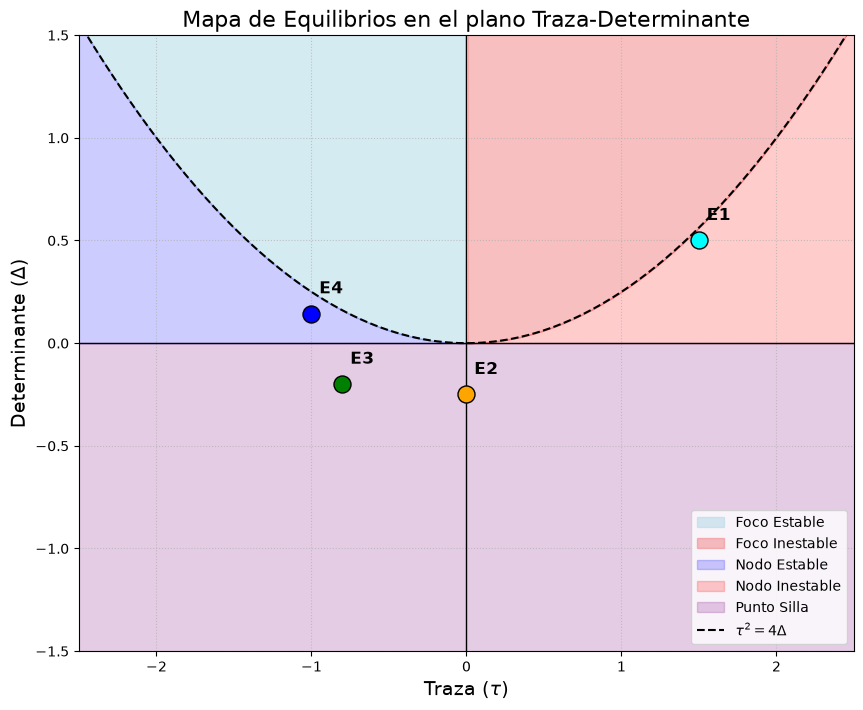

In [4]:
# Parámetros del Grupo 1
r1 = 1.0
r2 = 0.5
alpha12 = 0.5
alpha21 = 0.6

# Definición de los equilibrios factibles (calculados en Task 1.1)
equilibrios = {
    "E1 (0,0)": (0.0, 0.0),
    "E2 (0,1)": (0.0, 1.0),
    "E3 (1,0)": (1.0, 0.0),
    "E4 (Interior)": (5/7, 4/7) # 0.7143, 0.5714
}

# Función para calcular la jacobiana evaluada en (x,y)
def jacobiana(x, y):
    df1_dx = r1 * (1 - 2*x - alpha12*y)
    df1_dy = -r1 * alpha12 * x
    df2_dx = -r2 * alpha21 * y
    df2_dy = r2 * (1 - 2*y - alpha21*x)
    return np.array([[df1_dx, df1_dy], [df2_dx, df2_dy]])

# Función para clasificar el equilibrio según traza, determinante y discriminante 
# Basado en el mapa de equilibrios (Diapositiva S14)
def clasificar_equilibrio(tau, delta, discriminante):
    if delta < 0:
        return "Punto silla (Inestable)"
    elif delta > 0:
        if tau < 0:
            if discriminante >= 0:
                return "Nodo estable"
            else:
                return "Foco estable"
        elif tau > 0:
            if discriminante >= 0:
                return "Nodo inestable"
            else:
                return "Foco inestable"
        else: # tau == 0
            return "Centro"
    else:
        return "Caso frontera (Delta=0)"

# Evaluación y almacenamiento de datos para graficar
datos_plot = []

print("=== Evaluación de la Jacobiana en cada equilibrio factible ===\n")

for nombre, (x, y) in equilibrios.items():
    J = jacobiana(x, y)
    
    # Traza y determinante
    tau = np.trace(J)
    delta = np.linalg.det(J)
    discriminante = tau**2 - 4*delta
    
    # Valores propios
    eigenvalues = np.linalg.eigvals(J)
    
    # Clasificación
    clasificacion = clasificar_equilibrio(tau, delta, discriminante)
    
    # Guardar para el plot
    datos_plot.append((nombre, tau, delta, clasificacion))
    
    print(f"--- {nombre} ---")
    print(f"Jacobiana:\n{J}")
    print(f"Traza (tau): {tau:.4f}")
    print(f"Determinante (delta): {delta:.4f}")
    print(f"Discriminante (tau^2 - 4*delta): {discriminante:.4f}")
    print(f"Valores Propios (lambda): {eigenvalues}")
    print(f"Clasificación: {clasificacion}\n")

# --- Gráfica del plano Traza-Determinante (Task 1.2.c) ---
plt.figure(figsize=(10, 8))

# Generar datos para la parábola tau^2 = 4*delta (límite entre nodos y focos)
tau_vals = np.linspace(-3, 3, 400)
delta_vals = (tau_vals**2) / 4

# Dibujar regiones de estabilidad
plt.fill_between(tau_vals, delta_vals, 3, where=(tau_vals < 0), color='lightblue', alpha=0.5, label='Foco Estable')
plt.fill_between(tau_vals, delta_vals, 3, where=(tau_vals > 0), color='lightcoral', alpha=0.5, label='Foco Inestable')
plt.fill_between(tau_vals, 0, delta_vals, where=(tau_vals < 0), color='blue', alpha=0.2, label='Nodo Estable')
plt.fill_between(tau_vals, 0, delta_vals, where=(tau_vals > 0), color='red', alpha=0.2, label='Nodo Inestable')
plt.fill_between(tau_vals, -2, 0, color='purple', alpha=0.2, label='Punto Silla')

# Líneas base
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.plot(tau_vals, delta_vals, color='black', linestyle='--', label=r'$\tau^2 = 4\Delta$')

# Graficar puntos de los equilibrios
colores = ['cyan', 'orange', 'green', 'blue']
for i, (nombre, tau, delta, clas) in enumerate(datos_plot):
    plt.scatter(tau, delta, color=colores[i], s=150, edgecolor='black', zorder=5)
    plt.text(tau + 0.05, delta + 0.1, f"{nombre[:2]}", fontsize=12, fontweight='bold', zorder=6)

plt.xlim(-2.5, 2.5)
plt.ylim(-1.5, 1.5)
plt.xlabel(r'Traza ($\tau$)', fontsize=14)
plt.ylabel(r'Determinante ($\Delta$)', fontsize=14)
plt.title('Mapa de Equilibrios en el plano Traza-Determinante', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

## Task 1.3 
### c.Predicciones de convergencia para P1, P2, P3 y P4

Para cada uno de los estados iniciales P1, P2, P3 y P4, se predigio a cuál equilibrio converge el sistema.

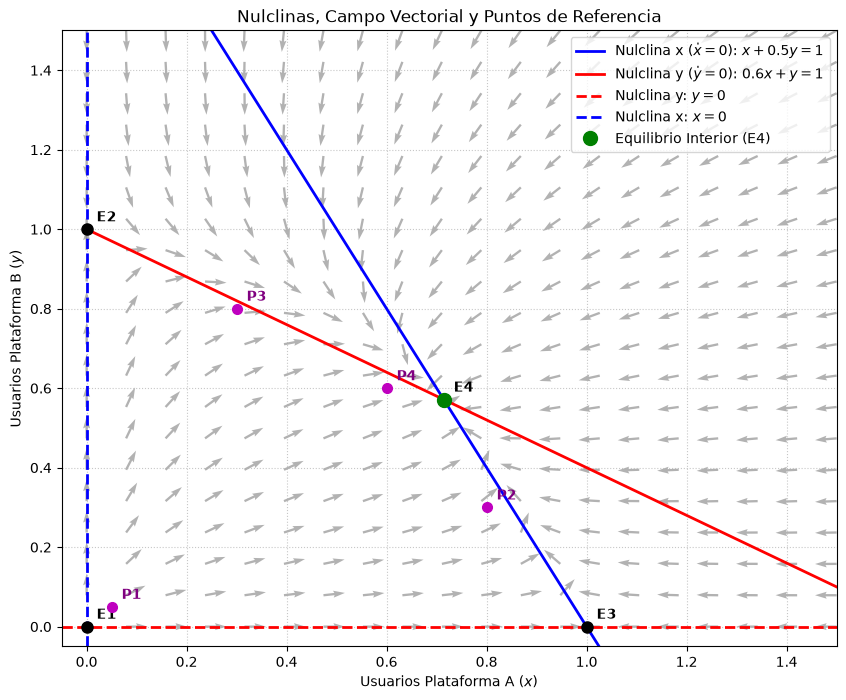

In [5]:
# Parámetros
alpha12 = 0.5
alpha21 = 0.6
r1 = 1.0
r2 = 0.5

# Puntos de equilibrio ya calculados
E1 = (0, 0)
E2 = (0, 1)
E3 = (1, 0)
E4 = (5/7, 4/7) # Aprox (0.714, 0.571)

# Puntos iniciales (Task 1.3.c)
puntos_iniciales = {
    'P1': (0.05, 0.05),
    'P2': (0.80, 0.30),
    'P3': (0.30, 0.80),
    'P4': (0.60, 0.60)
}

# Configuración de la malla para el campo vectorial
x = np.linspace(0, 1.5, 20)
y = np.linspace(0, 1.5, 20)
X, Y = np.meshgrid(x, y)

# Campo vectorial
U = r1 * X * (1 - X - alpha12 * Y)
V = r2 * Y * (1 - Y - alpha21 * X)

# Normalización del campo vectorial para que las flechas tengan igual longitud
norm = np.sqrt(U**2 + V**2)
norm[norm == 0] = 1 # Evitar división por cero
U_norm = U / norm
V_norm = V / norm

# Vectores para trazar las nulclinas
x_line = np.linspace(0, 1.5, 100)
# Nulclina x: y = 2 - 2x
y_nul_x = (1 - x_line) / alpha12
# Nulclina y: y = 1 - 0.6x
y_nul_y = 1 - alpha21 * x_line

plt.figure(figsize=(10, 8))

# Nulclinas principales
plt.plot(x_line, y_nul_x, 'b-', label='Nulclina x ($\\dot{x}=0$): $x + 0.5y = 1$', linewidth=2)
plt.plot(x_line, y_nul_y, 'r-', label='Nulclina y ($\\dot{y}=0$): $0.6x + y = 1$', linewidth=2)

# Nulclinas sobre los ejes (x=0, y=0)
plt.axhline(0, color='r', linestyle='--', linewidth=2, label='Nulclina y: $y=0$')
plt.axvline(0, color='b', linestyle='--', linewidth=2, label='Nulclina x: $x=0$')

# Campo vectorial
plt.quiver(X, Y, U_norm, V_norm, color='gray', alpha=0.6)

# Equilibrios
plt.plot(*E1, 'ko', markersize=8, zorder=5)
plt.text(E1[0]+0.02, E1[1]+0.02, 'E1', fontweight='bold')
plt.plot(*E2, 'ko', markersize=8, zorder=5)
plt.text(E2[0]+0.02, E2[1]+0.02, 'E2', fontweight='bold')
plt.plot(*E3, 'ko', markersize=8, zorder=5)
plt.text(E3[0]+0.02, E3[1]+0.02, 'E3', fontweight='bold')
plt.plot(*E4, 'go', markersize=10, zorder=5, label='Equilibrio Interior (E4)')
plt.text(E4[0]+0.02, E4[1]+0.02, 'E4', fontweight='bold')

# Puntos iniciales
for nombre, (px, py) in puntos_iniciales.items():
    plt.plot(px, py, 'mo', markersize=7, zorder=5)
    plt.text(px+0.02, py+0.02, nombre, color='purple', fontweight='bold')

plt.xlim(-0.05, 1.5)
plt.ylim(-0.05, 1.5)
plt.xlabel('Usuarios Plataforma A ($x$)')
plt.ylabel('Usuarios Plataforma B ($y$)')
plt.title('Nulclinas, Campo Vectorial y Puntos de Referencia')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Task 2.1: Implementación de integradores y análisis de error

### a. Implementación de los métodos de Euler y Runge-Kutta
Se implementa desde cero las funciones para el método de Euler y el método de Runge-Kutta de cuarto orden (RK4). Ambos algoritmos recibirán la función vectorial `f(t, state)`, el estado inicial, el tamaño del paso `h` y el tiempo final `T`. 

### b. Cálculo de errores respecto a la solución de referencia
Se usara `solve_ivp` de SciPy con el método `DOP853` (tolerancias $10^{-12}$) como solución de "verdad fundamental" para el estado $P2(0.80, 0.30)$ en $T=10$. El error se medirá como la norma euclidiana entre el estado final obtenido por nuestros integradores y el estado final de la referencia para los pasos $h \in \{0.2, 0.1, 0.05, 0.025, 0.0125\}$.

### c. Grafica del error contra el paso en escala log-log
Se grafica para ambos métodos, estimando la pendiente de cada recta por regresión.

Estado final de referencia (DOP853) en T=10.0: x=0.756882, y=0.503070

h = 0.2000 | Error Euler: 1.06e-03 | Error RK4: 3.06e-09
h = 0.1000 | Error Euler: 5.27e-04 | Error RK4: 1.79e-10
h = 0.0500 | Error Euler: 2.63e-04 | Error RK4: 1.04e-11
h = 0.0250 | Error Euler: 1.31e-04 | Error RK4: 3.53e-13
h = 0.0125 | Error Euler: 6.56e-05 | Error RK4: 3.70e-13


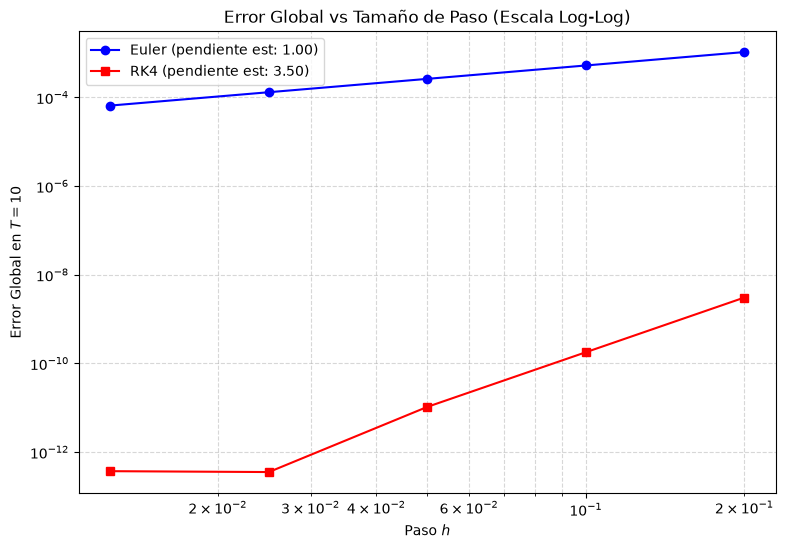

In [6]:
from scipy.integrate import solve_ivp
from scipy.stats import linregress

# Parámetros Grupo 1
r1 = 1.0
r2 = 0.5
alpha12 = 0.5
alpha21 = 0.6

# Definición del campo vectorial f(t, x)
def f(t, state):
    x, y = state
    dxdt = r1 * x * (1 - x - alpha12 * y)
    dydt = r2 * y * (1 - y - alpha21 * x)
    return np.array([dxdt, dydt])

# a. Método de Euler desde cero
def euler(f, y0, h, T):
    # Creamos el vector de tiempos. Se suma h/2 para asegurar incluir el tiempo final T.
    t_vals = np.arange(0, T + h/2, h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0
    
    for i in range(1, len(t_vals)):
        y_vals[i] = y_vals[i-1] + h * f(t_vals[i-1], y_vals[i-1])
        
    return y_vals[-1] # Solo devolvemos el estado final para el cálculo de error

# a. Método de Runge-Kutta de 4to orden (RK4) desde cero
def rk4(f, y0, h, T):
    t_vals = np.arange(0, T + h/2, h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0
    
    for i in range(1, len(t_vals)):
        t = t_vals[i-1]
        y = y_vals[i-1]
        
        k1 = f(t, y)
        k2 = f(t + h/2, y + (h/2) * k1)
        k3 = f(t + h/2, y + (h/2) * k2)
        k4 = f(t + h, y + h * k3)
        
        y_vals[i] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return y_vals[-1]

# b. Configuración y cálculo contra la referencia
y0_P2 = np.array([0.80, 0.30])
T = 10.0
h_vals = [0.2, 0.1, 0.05, 0.025, 0.0125]

# Solución de referencia usando solve_ivp con DOP853
sol_ref = solve_ivp(f, [0, T], y0_P2, method='DOP853', atol=1e-12, rtol=1e-12)
y_ref = sol_ref.y[:, -1] # Extraemos el punto final exacto

errors_euler = []
errors_rk4 = []

print(f"Estado final de referencia (DOP853) en T={T}: x={y_ref[0]:.6f}, y={y_ref[1]:.6f}\n")

for h in h_vals:
    y_euler = euler(f, y0_P2, h, T)
    y_rk4 = rk4(f, y0_P2, h, T)
    
    # Error global (Norma Euclidiana de la diferencia)
    err_eu = np.linalg.norm(y_euler - y_ref)
    err_rk = np.linalg.norm(y_rk4 - y_ref)
    
    errors_euler.append(err_eu)
    errors_rk4.append(err_rk)
    print(f"h = {h:6.4f} | Error Euler: {err_eu:.2e} | Error RK4: {err_rk:.2e}")

# c. Regresión lineal para estimar pendientes en log-log
h_arr = np.array(h_vals)
log_h = np.log10(h_arr)
log_err_eu = np.log10(np.array(errors_euler))
log_err_rk = np.log10(np.array(errors_rk4))

slope_eu, _, _, _, _ = linregress(log_h, log_err_eu)
slope_rk, _, _, _, _ = linregress(log_h, log_err_rk)

# Gráfica log-log
plt.figure(figsize=(9, 6))
plt.plot(h_arr, errors_euler, 'o-', color='blue', label=f'Euler (pendiente est: {slope_eu:.2f})')
plt.plot(h_arr, errors_rk4, 's-', color='red', label=f'RK4 (pendiente est: {slope_rk:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Paso $h$')
plt.ylabel('Error Global en $T=10$')
plt.title('Error Global vs Tamaño de Paso (Escala Log-Log)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Task 2.2: Retrato de fases y validación de predicciones

### a. y b. Construcción del retrato de fases y marcado de equilibrios
Se construye el retrato de fases en el cuadrante $[0, 1.5] \times [0, 1.5]$. El gráfico incluye:
- El campo vectorial con flechas normalizadas.
- Las dos nulclinas.
- Más de doce trayectorias de fondo generadas con el método de Runge-Kutta (RK4) desde varios estados iniciales (incluyendo cerca de los ejes).
- Los equilibrios marcados por color (rojo para los inestables/silla, verde para el nodo estable).
- Las cuatro trayectorias de los estados de referencia (P1, P2, P3 y P4) resaltadas con colores y mayor grosor.

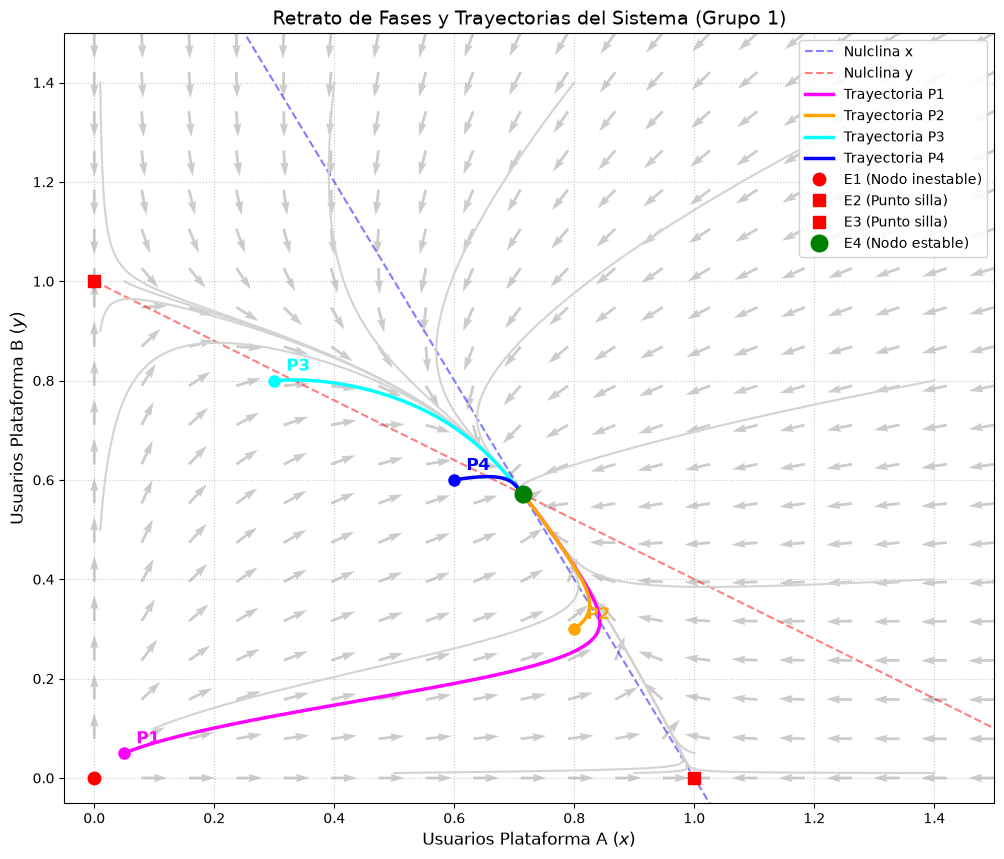

In [7]:
# Parámetros Grupo 1
r1 = 1.0; r2 = 0.5
alpha12 = 0.5; alpha21 = 0.6

# Ecuaciones del sistema
def f(t, state):
    x, y = state
    dxdt = r1 * x * (1 - x - alpha12 * y)
    dydt = r2 * y * (1 - y - alpha21 * x)
    return np.array([dxdt, dydt])

# Integrador RK4 desde cero (reutilizado de la celda anterior)
def rk4_trayectoria(f, y0, h, T):
    t_vals = np.arange(0, T + h/2, h)
    y_vals = np.zeros((len(t_vals), len(y0)))
    y_vals[0] = y0
    for i in range(1, len(t_vals)):
        t = t_vals[i-1]; y = y_vals[i-1]
        k1 = f(t, y)
        k2 = f(t + h/2, y + (h/2) * k1)
        k3 = f(t + h/2, y + (h/2) * k2)
        k4 = f(t + h, y + h * k3)
        y_vals[i] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    return y_vals

# 1. Configuración de la malla para el campo vectorial
x_val = np.linspace(0, 1.5, 20)
y_val = np.linspace(0, 1.5, 20)
X, Y = np.meshgrid(x_val, y_val)
U = r1 * X * (1 - X - alpha12 * Y)
V = r2 * Y * (1 - Y - alpha21 * X)

norm = np.sqrt(U**2 + V**2)
norm[norm == 0] = 1 # Evitar división por cero
U_norm = U / norm
V_norm = V / norm

plt.figure(figsize=(12, 10))

# Campo vectorial
plt.quiver(X, Y, U_norm, V_norm, color='gray', alpha=0.4)

# 2. Nulclinas
x_line = np.linspace(0, 1.5, 100)
y_nul_x = (1 - x_line) / alpha12
y_nul_y = 1 - alpha21 * x_line
plt.plot(x_line, y_nul_x, 'b--', alpha=0.5, label='Nulclina x')
plt.plot(x_line, y_nul_y, 'r--', alpha=0.5, label='Nulclina y')

# 3. Múltiples trayectorias de fondo (al menos 12)
estados_fondo = [
    (0.01, 1.4), (1.4, 0.01), (0.01, 0.5), (0.5, 0.01), 
    (0.1, 0.1), (1.4, 1.4), (0.8, 1.4), (1.4, 0.8),
    (0.05, 1.0), (1.0, 0.05), (0.4, 1.4), (1.4, 0.4),
    (0.01, 0.9), (0.9, 0.01) # Cerca de los ejes
]
h_sim = 0.1
T_sim = 25

for y0 in estados_fondo:
    traj = rk4_trayectoria(f, y0, h_sim, T_sim)
    plt.plot(traj[:, 0], traj[:, 1], color='lightgray', linewidth=1.5)

# 4. Trayectorias de referencia P1-P4
puntos_ref = {'P1': (0.05, 0.05), 'P2': (0.80, 0.30), 'P3': (0.30, 0.80), 'P4': (0.60, 0.60)}
colores = {'P1': 'magenta', 'P2': 'orange', 'P3': 'cyan', 'P4': 'blue'}

for nombre, pt in puntos_ref.items():
    traj = rk4_trayectoria(f, pt, h_sim, T_sim)
    # Dibujar línea de trayectoria
    plt.plot(traj[:, 0], traj[:, 1], color=colores[nombre], linewidth=2.5, label=f'Trayectoria {nombre}')
    # Dibujar punto inicial
    plt.plot(pt[0], pt[1], 'o', color=colores[nombre], markersize=8)
    plt.text(pt[0]+0.02, pt[1]+0.02, nombre, fontsize=12, fontweight='bold', color=colores[nombre])

# 5. Marcado de equilibrios
plt.plot(0, 0, 'ro', markersize=9, label='E1 (Nodo inestable)')
plt.plot(0, 1, 'rs', markersize=8, label='E2 (Punto silla)')
plt.plot(1, 0, 'rs', markersize=8, label='E3 (Punto silla)')
plt.plot(5/7, 4/7, 'go', markersize=12, label='E4 (Nodo estable)')

# Formato final de la gráfica
plt.xlim(-0.05, 1.5)
plt.ylim(-0.05, 1.5)
plt.xlabel('Usuarios Plataforma A ($x$)', fontsize=12)
plt.ylabel('Usuarios Plataforma B ($y$)', fontsize=12)
plt.title('Retrato de Fases y Trayectorias del Sistema (Grupo 1)', fontsize=14)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Task 2.3: Cuencas de atracción

### a. Criterio de convergencia y configuración de la malla
Para determinar a qué equilibrio llega cada estado de la malla $60 \times 60$, necesitamos un criterio de convergencia. 

**Criterio definido:** Un estado se considera estabilizado en un equilibrio si la distancia euclidiana entre el estado actual del sistema y las coordenadas exactas de dicho equilibrio es menor a una tolerancia estricta. Alternativamente, el sistema ha convergido si la norma del vector de derivadas $||\dot{x}, \dot{y}||$ cae por debajo de $10^{-5}$, lo que significa que el estado prácticamente ha dejado de moverse. Se usara la distancia a los equilibrios conocidos para etiquetar cada punto.

La malla se construirá uniformemente en el intervalo $[0.01, 1.5] \times [0.01, 1.5]$ para evitar evaluar exactamente sobre los ejes.

Simulando malla de cuencas (puede tardar unos segundos)...
Fracción del cuadrante en la cuenca de E4: 100.00%


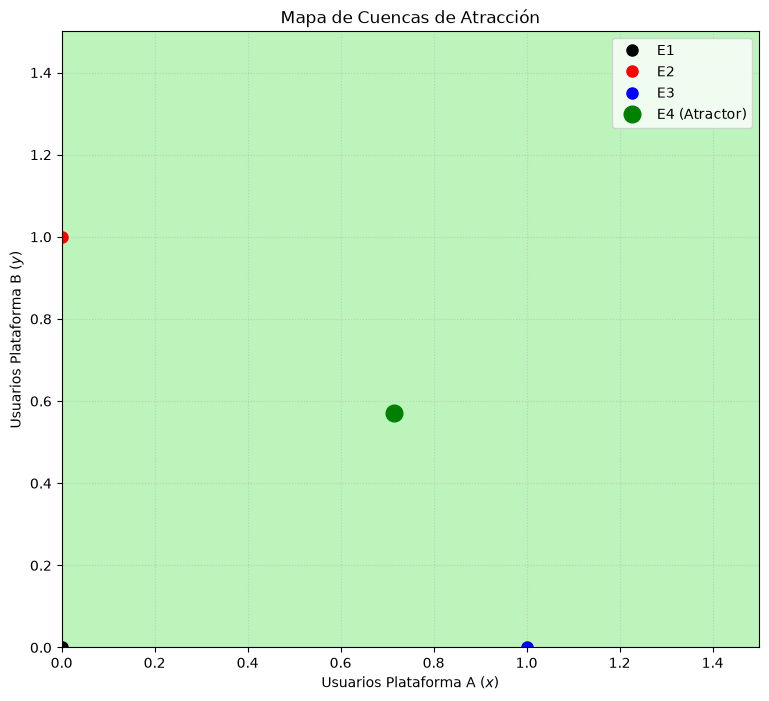

In [8]:
from matplotlib.colors import ListedColormap

# Parámetros Grupo 1
r1 = 1.0; r2 = 0.5
alpha12 = 0.5; alpha21 = 0.6

# Equilibrios
E1 = np.array([0.0, 0.0])
E2 = np.array([0.0, 1.0])
E3 = np.array([1.0, 0.0])
E4 = np.array([5/7, 4/7])
equilibrios = [E1, E2, E3, E4]

def f(t, state):
    x, y = state
    return np.array([r1 * x * (1 - x - alpha12 * y), 
                     r2 * y * (1 - y - alpha21 * x)])

# Integrador RK4 optimizado (solo devuelve el último estado tras T tiempo)
def rk4_final(y0, h, T):
    pasos = int(T / h)
    y = np.array(y0, dtype=float)
    t = 0.0
    for _ in range(pasos):
        k1 = f(t, y)
        k2 = f(t + h/2, y + (h/2) * k1)
        k3 = f(t + h/2, y + (h/2) * k2)
        k4 = f(t + h, y + h * k3)
        y += (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t += h
    return y

# Generación de la malla 60x60
N = 60
x_vals = np.linspace(0.01, 1.5, N)
y_vals = np.linspace(0.01, 1.5, N)
X, Y = np.meshgrid(x_vals, y_vals)

cuencas = np.zeros((N, N))

# Parámetros de simulación
h_sim = 0.2 # Paso relativamente grande para velocidad, Euler requeriría uno menor
T_sim = 50.0 # Tiempo suficiente para converger
tolerancia = 1e-2

print("Simulando malla de cuencas (puede tardar unos segundos)...")

# Simular cada punto de la malla
for i in range(N):
    for j in range(N):
        estado_inicial = [X[i, j], Y[i, j]]
        estado_final = rk4_final(estado_inicial, h_sim, T_sim)
        
        # Identificar a qué equilibrio convergió
        distancias = [np.linalg.norm(estado_final - eq) for eq in equilibrios]
        min_dist_idx = np.argmin(distancias)
        
        if distancias[min_dist_idx] < tolerancia:
            cuencas[i, j] = min_dist_idx + 1 # 1:E1, 2:E2, 3:E3, 4:E4
        else:
            cuencas[i, j] = 0 # 0: No convergió (o lo hizo a otro lado)

# Calcular fracción
fraccion_E4 = np.sum(cuencas == 4) / (N * N)
print(f"Fracción del cuadrante en la cuenca de E4: {fraccion_E4 * 100:.2f}%")

# Gráfica
plt.figure(figsize=(9, 8))
# Colores: 0=Blanco(no converge), 1=Gris(E1), 2=Rojo(E2), 3=Azul(E3), 4=Verde Claro(E4)
cmap = ListedColormap(['white', 'gray', 'red', 'blue', 'lightgreen'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

plt.pcolormesh(X, Y, cuencas, cmap=cmap, norm=norm, shading='nearest', alpha=0.6)

# Marcar equilibrios
plt.plot(*E1, 'ko', markersize=8, label='E1')
plt.plot(*E2, 'ro', markersize=8, label='E2')
plt.plot(*E3, 'bo', markersize=8, label='E3')
plt.plot(*E4, 'go', markersize=12, label='E4 (Atractor)')

plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.xlabel('Usuarios Plataforma A ($x$)')
plt.ylabel('Usuarios Plataforma B ($y$)')
plt.title('Mapa de Cuencas de Atracción')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

## Task 2.4: Cuencas de atracción

### a. Perturbaciones en 8 direcciones
Se establece un régimen por una distancia en ocho direcciones distintas, igualmente espaciadas, que mantengan el estado dentro del cuadrante.

### b. Bisección numérica para encontrar h_max de Euler
Se comparan las tasas medidas calculando en el task 1.2, con un reporte relativo.

In [10]:
from scipy.stats import linregress

# Parámetros del sistema
r1 = 1.0; r2 = 0.5
alpha12 = 0.5; alpha21 = 0.6
E4 = np.array([5/7, 4/7])

# Valores teóricos calculados previamente
lambda_1 = -0.82732684
lambda_2 = -0.17267316
min_re_lambda = min(abs(lambda_1), abs(lambda_2))
h_max_teorico = 2 / abs(lambda_1)

def f(t, state):
    x, y = state
    return np.array([r1 * x * (1 - x - alpha12 * y), 
                     r2 * y * (1 - y - alpha21 * x)])

# Integrador RK4
def rk4_traj(y0, h, T):
    t_vals = np.arange(0, T + h/2, h)
    y_vals = np.zeros((len(t_vals), 2))
    y_vals[0] = y0
    for i in range(1, len(t_vals)):
        k1 = f(t_vals[i-1], y_vals[i-1])
        k2 = f(t_vals[i-1] + h/2, y_vals[i-1] + (h/2)*k1)
        k3 = f(t_vals[i-1] + h/2, y_vals[i-1] + (h/2)*k2)
        k4 = f(t_vals[i-1] + h, y_vals[i-1] + h*k3)
        y_vals[i] = y_vals[i-1] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t_vals, y_vals

# a. Perturbaciones en 8 direcciones
angulos = np.linspace(0, 2*np.pi, 8, endpoint=False)
dist_inicial = 1e-4

print("--- Tasa de Decaimiento por Dirección (Task 2.4.a y 2.4.b) ---")
print(f"Decaimiento teórico min|Re(lambda)| = {min_re_lambda:.6f}\n")

for i, theta in enumerate(angulos):
    perturbacion = dist_inicial * np.array([np.cos(theta), np.sin(theta)])
    y0 = E4 + perturbacion
    
    # Simular
    t_vals, traj = rk4_traj(y0, h=0.1, T=100.0)
    normas = np.linalg.norm(traj - E4, axis=1)
    
    # Filtrar ventana: 10^-4 a 10^-6
    # Usamos <= 1.01e-4 para asegurarnos de capturar el inicio por errores de redondeo
    indices = np.where((normas <= 1.01e-4) & (normas >= 1e-6))[0]
    
    if len(indices) > 2:
        t_window = t_vals[indices]
        log_normas = np.log(normas[indices])
        
        # Ajuste de recta
        slope, _, _, _, _ = linregress(t_window, log_normas)
        tasa_medida = abs(slope) # La tasa de decaimiento es la magnitud de la pendiente
        error_relativo = abs(tasa_medida - min_re_lambda) / min_re_lambda * 100
        
        print(f"Dir {i+1} ({theta*180/np.pi:>5.1f}°): Tasa medida = {tasa_medida:.6f} | Err Relativo = {error_relativo:.2f}%")

# d. Bisección numérica para encontrar h_max de Euler
def eval_euler_convergencia(h):
    y = E4 + np.array([1e-4, 1e-4]) # Pequeña perturbación
    t = 0
    T_max = 500.0
    while t < T_max:
        deriv = f(t, y)
        y = y + h * deriv
        # Si se sale del cuadrante o explota, divergió
        if np.any(np.isnan(y)) or np.linalg.norm(y - E4) > 1.5:
            return False
        t += h
    return np.linalg.norm(y - E4) < 1e-3

print("\n--- Bisección Numérica para h_max de Euler (Task 2.4.d) ---")
print(f"Límite teórico lineal: h_max = {h_max_teorico:.4f}")

# Bisección
h_izq = 1.0
h_der = 4.0
tolerancia_h = 1e-4

while (h_der - h_izq) > tolerancia_h:
    h_medio = (h_izq + h_der) / 2
    if eval_euler_convergencia(h_medio):
        h_izq = h_medio # Converge, intentar un paso mayor
    else:
        h_der = h_medio # Diverge, intentar un paso menor

h_max_numerico = h_izq
print(f"Límite numérico encontrado: h_max = {h_max_numerico:.4f}")

--- Tasa de Decaimiento por Dirección (Task 2.4.a y 2.4.b) ---
Decaimiento teórico min|Re(lambda)| = 0.172673

Dir 1 (  0.0°): Tasa medida = 0.197087 | Err Relativo = 14.14%
Dir 2 ( 45.0°): Tasa medida = 0.178681 | Err Relativo = 3.48%
Dir 3 ( 90.0°): Tasa medida = 0.171880 | Err Relativo = 0.46%
Dir 4 (135.0°): Tasa medida = 0.173555 | Err Relativo = 0.51%
Dir 5 (180.0°): Tasa medida = 0.197088 | Err Relativo = 14.14%
Dir 6 (225.0°): Tasa medida = 0.178676 | Err Relativo = 3.48%
Dir 7 (270.0°): Tasa medida = 0.171872 | Err Relativo = 0.46%
Dir 8 (315.0°): Tasa medida = 0.173549 | Err Relativo = 0.51%

--- Bisección Numérica para h_max de Euler (Task 2.4.d) ---
Límite teórico lineal: h_max = 2.4174
Límite numérico encontrado: h_max = 2.4288


## Task 2.5
### b. Valor crítico de rivalidad ($\alpha_{21}$)
Para que el régimen cambie de manera cualitativa , el equilibrio interior $E_4$ debe chocar contra uno de los equilibrios sobre los ejes en una bifurcación transcrítica.


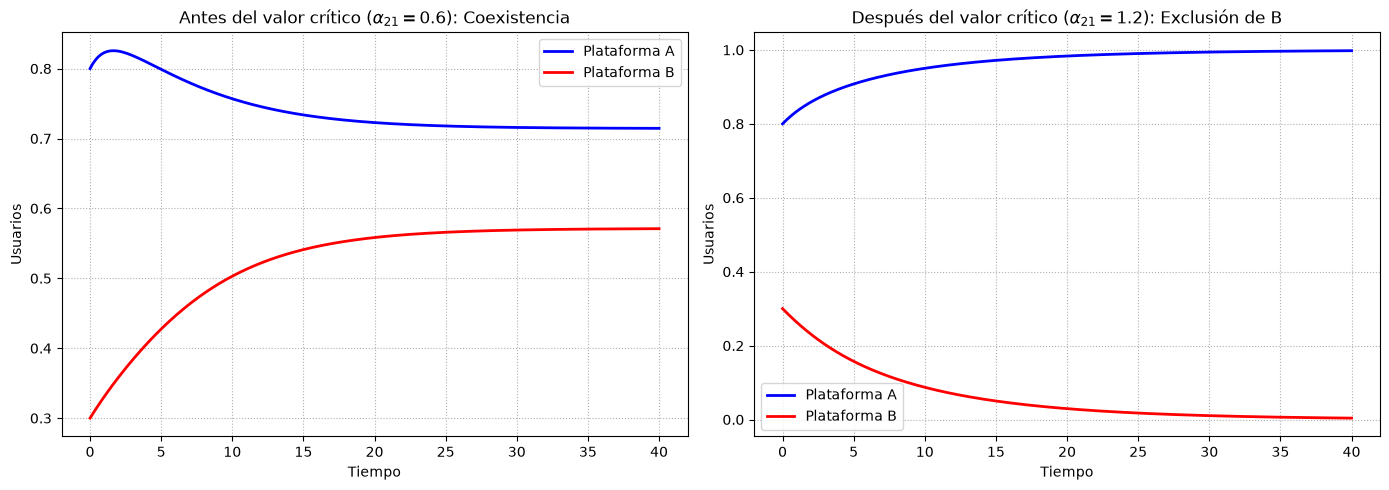

In [11]:
# Parámetros base
r1 = 1.0; r2 = 0.5
alpha12 = 0.5

def f_sim(t, state, a21):
    x, y = state
    dxdt = r1 * x * (1 - x - alpha12 * y)
    dydt = r2 * y * (1 - y - a21 * x)
    return np.array([dxdt, dydt])

# Integrador RK4 
def rk4_trayectoria(y0, h, T, a21):
    t_vals = np.arange(0, T + h/2, h)
    y_vals = np.zeros((len(t_vals), 2))
    y_vals[0] = y0
    for i in range(1, len(t_vals)):
        t = t_vals[i-1]; y = y_vals[i-1]
        k1 = f_sim(t, y, a21)
        k2 = f_sim(t + h/2, y + (h/2)*k1, a21)
        k3 = f_sim(t + h/2, y + (h/2)*k2, a21)
        k4 = f_sim(t + h, y + h*k3, a21)
        y_vals[i] = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t_vals, y_vals

y0_P2 = np.array([0.80, 0.30])
h_paso = 0.1
T_sim = 40.0

# 1. Simulación antes del valor crítico
t1, traj1 = rk4_trayectoria(y0_P2, h_paso, T_sim, a21=0.6)

# 2. Simulación después del valor crítico
t2, traj2 = rk4_trayectoria(y0_P2, h_paso, T_sim, a21=1.2)

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Coexistencia
ax1.plot(t1, traj1[:, 0], 'b-', linewidth=2, label='Plataforma A')
ax1.plot(t1, traj1[:, 1], 'r-', linewidth=2, label='Plataforma B')
ax1.set_title(r'Antes del valor crítico ($\alpha_{21} = 0.6$): Coexistencia')
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Usuarios')
ax1.legend()
ax1.grid(True, ls=':')

# Plot Exclusión
ax2.plot(t2, traj2[:, 0], 'b-', linewidth=2, label='Plataforma A')
ax2.plot(t2, traj2[:, 1], 'r-', linewidth=2, label='Plataforma B')
ax2.set_title(r'Después del valor crítico ($\alpha_{21} = 1.2$): Exclusión de B')
ax2.set_xlabel('Tiempo')
ax2.set_ylabel('Usuarios')
ax2.legend()
ax2.grid(True, ls=':')

plt.tight_layout()
plt.show()